# 00. Homework description

For this assignment, your task is to develop the [FastPitch](https://arxiv.org/abs/2006.06873) synthesis model, train it, and generate several audio samples.

The training and data processing code has already been provided for you. The training will be conducted on the LJspeech dataset.

The total score for the homework is **10 points**, distributed as follows:
- 1 point for visualizing the input data
- 8 points for writing the model code and running training
- 1 point for pitch and duration manipulations during inference

The homework submission **should include**:
- Completed notebook
- Attached WER and loss graphs from TensorBoard
- 1 audio file - the result of a regular model inference
- 4 additional audio files: you are encouraged to experiment with adjusting phoneme durations and pitch slightly and listen to the results.

# 01. Preparation steps

In [1]:
!pip install praat-parselmouth soundfile librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 32.5 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/crustaceano/speech_course.git

Cloning into 'speech_course'...
remote: Enumerating objects: 1225, done.
remote: Counting objects: 100% (443/443), done.
remote: Compressing objects: 100% (270/270), done.
remote: Total 1225 (delta 240), reused 181 (delta 173), pack-reused 782 (from 3)
Receiving objects: 100% (1225/1225), 175.97 MiB | 16.00 MiB/s, done.
Resolving deltas: 100% (558/558), done.


In [3]:
device = "cuda"
gpu_avaiable = "1"    # Run nvidia-smi to find free GPU

In [4]:
path_to_sources = '/content/speech_course/week_08_tts_am_vocoders'

In [6]:
!pip install -r '/content/speech_course/week_08_tts_am_vocoders/requirements.txt'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.1 MB/s eta 0:00:00


In [5]:
# If running in colab

# clone the repository:
# git clone https://github.com/yandexdataschool/speech_course.git
# !pip install -r speech_course/week_08_tts_am_vocoders/requirements.txt

### Dataset

We will work with [LJSpeech](https://keithito.com/LJ-Speech-Dataset/) -- a single-speaker dataset with 24 hours of speech.

The data we will use contains pre-computed [MFA-alignments](https://montreal-forced-aligner.readthedocs.io/en/latest/user_guide/workflows/alignment.html) alongside with the original wavs and texts. If you are interested in the process of extracting such alignments, please refer to this [tutorial](https://colab.research.google.com/gist/NTT123/12264d15afad861cb897f7a20a01762e/mfa-ljspeech.ipynb).

Download the dataset with precomputed alignments.

In [7]:
import requests
from urllib.parse import urlencode
from io import BytesIO
from zipfile import ZipFile

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/PpgePfWcQTAbug'

final_url = base_url + urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']
response = requests.get(download_url)

# path_to_dataset = 'data/ljspeech'    # Choose any appropriate local path

# If running in Colab:
path_to_dataset = '/content/ljspeech_aligned'

zipfile = ZipFile(BytesIO(response.content))
zipfile.extractall(path=path_to_dataset)

### Hi-Fi GAN checkpoint


Download a pretrained Hi-Fi GAN checkpoint (to generate audio from the predicted mel-spectrograms).

In [8]:
!wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/dle/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/zip -O hifigan_ckpt.zip
!unzip hifigan_ckpt.zip
!rm hifigan_ckpt.zip

--2026-04-13 18:13:32--  https://api.ngc.nvidia.com/v2/models/nvidia/dle/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/zip
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 54.203.64.172, 44.224.253.220
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|54.203.64.172|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/dle/models/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/files.zip?ssec-algo=AES256&versionId=9Z5wUkSi5Ca0OVT_KuDtXvkMxim8mDiL&ssec-key=GRquBvogTGpbgci%2F0Wx4l%2BfWP6lmL7cc09MstFGhpjgUKC58buzOyVhbFXjlDHY3Ba3qGAsil%2F5rRKOLs6kyGlNi64zxeyG3BOwVFRgifm5aHTvoTHBUjyqkkvsVxe%2FZZdbeIQywgbcd3uQkvZPEpdidipc%2B9xFlykxDELMzwWJMF%2Bgu6Tc9Ys2hdfyHBgT1oN%2FUje7sH8dr5lvvcNrwwvBhulUo5vpJu5bMnxqDXsXaBmaVwe%2FpUZQNShCwQaXAdKSEvMXkH9rwRIgIYHYplC4I7mbwZZ73gm5zSobd2KFhO58yo5%2F9sYpZJBkLd2o1JKjrRl4kiQjT03AVJLnxx22wkIK7oLvuCjnelXb8DebwAGVsVPrlz7ToD4If2ljDGvRNhekMqeKUlVljzKwAsJdIm0VK8nIBmThTapXGZNqkCU03ZpKSA

In [9]:
path_to_hfg_ckpt = "hifigan_gen_checkpoint_6500.pt"

### Imports

In [10]:
!pip install g2p_en

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.7 MB/s eta 0:00:00
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=d80ce6c8c0b7ba22cade58d184825eea431ba486686e88616f4e439e25550529
  Stored in directory: /root/.cache/pip/wheels/24/a8/58/407063d8e5c1d4dd6594c99d12baa0108570b56a92325587dd
Successfully built distance


In [11]:
import sys
import os
import json
import dataclasses
import torch
import subprocess as sp
import matplotlib.pylab as plt
import soundfile as sf

from g2p_en import G2p
import IPython.display as Ipd

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.


In [12]:
sys.path.append(path_to_sources)

# 02. See a data sample (1 point)

In [13]:
from sources.fastpitch.hparams import HParamsFastpitch
from sources.fastpitch.data import prepare_loaders, SymbolsSet

In [14]:
symbol_set = SymbolsSet()

The mfa alignment provides phonemes and their durations, which we will need during training:

In [15]:
with open(os.path.join(path_to_dataset, 'mfa_aligned', 'LJ001-0001.json')) as f:
  utterance = json.load(f)

utterance

{'start': 0,
 'end': 9.655062,
 'tiers': {'words': {'type': 'interval',
   'entries': [[0.0, 0.69, 'printing'],
    [0.69, 0.82, '<eps>'],
    [0.82, 1.01, 'in'],
    [1.01, 1.15, 'the'],
    [1.15, 1.45, 'only'],
    [1.45, 1.97, 'sense'],
    [1.97, 2.14, 'with'],
    [2.14, 2.39, 'which'],
    [2.39, 2.54, 'we'],
    [2.54, 2.71, 'are'],
    [2.71, 2.89, 'at'],
    [2.89, 3.28, 'present'],
    [3.28, 4.0, 'concerned'],
    [4.0, 4.41, '<eps>'],
    [4.41, 5.01, 'differs'],
    [5.01, 5.04, '<eps>'],
    [5.04, 5.28, 'from'],
    [5.28, 5.65, 'most'],
    [5.65, 5.82, 'if'],
    [5.82, 6.1, 'not'],
    [6.1, 6.29, 'from'],
    [6.29, 6.63, 'all'],
    [6.63, 6.78, 'the'],
    [6.78, 7.09, 'arts'],
    [7.09, 7.22, 'and'],
    [7.22, 7.8, 'crafts'],
    [7.8, 8.45, 'represented'],
    [8.45, 8.66, 'in'],
    [8.66, 8.79, 'the'],
    [8.79, 9.6, 'exhibition'],
    [9.6, 9.655062, '<eps>']]},
  'phones': {'type': 'interval',
   'entries': [[0.0, 0.04, 'P'],
    [0.04, 0.07, 'R'],
    [0

Phoneme `sil` here denotes pause -- a period of silence between spoken phonemes. The phonemes are from [ARPA](https://en.wikipedia.org/wiki/ARPABET) alphabet.

In [16]:
hparams = HParamsFastpitch()
train_loader, val_loader = prepare_loaders(path_to_dataset, hparams)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [17]:
train_iter = iter(train_loader)
batch = next(train_iter)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [18]:
list(dataclasses.asdict(batch).keys())

['texts',
 'text_lengths',
 'mels',
 'mel_lengths',
 'pitches',
 'durations',
 'paces']

In [19]:
batch.mels.shape

torch.Size([10, 80, 862])

In [20]:
batch.pitches.shape

torch.Size([10, 119])

In [21]:
batch.durations.shape

torch.Size([10, 119])

In [33]:
batch

FastPitchBatch(texts=tensor([[ 6, 32, 53,  ...,  0,  0,  0],
        [20,  1, 41,  ...,  0,  0,  0],
        [ 4, 31, 56,  ...,  0,  0,  0],
        ...,
        [69,  6, 40,  ...,  0,  0,  0],
        [ 4, 56, 21,  ...,  0,  0,  0],
        [43, 23, 43,  ...,  0,  0,  0]]), text_lengths=tensor([ 70,  66,  71, 119,  95,  84,  62, 100,  81, 100]), mels=tensor([[[ -7.9953,  -6.5572,  -6.1878,  ...,   0.0000,   0.0000,   0.0000],
         [ -6.6666,  -5.4659,  -4.8703,  ...,   0.0000,   0.0000,   0.0000],
         [ -5.1991,  -4.1378,  -3.9543,  ...,   0.0000,   0.0000,   0.0000],
         ...,
         [ -9.8542,  -9.5700,  -9.4342,  ...,   0.0000,   0.0000,   0.0000],
         [ -9.9269,  -9.6356,  -9.6327,  ...,   0.0000,   0.0000,   0.0000],
         [ -9.3677,  -9.1694,  -9.5036,  ...,   0.0000,   0.0000,   0.0000]],

        [[ -6.8163,  -7.2954,  -6.3854,  ...,   0.0000,   0.0000,   0.0000],
         [ -6.5766,  -6.9819,  -6.4227,  ...,   0.0000,   0.0000,   0.0000],
         [ -6.

In [34]:
batch.text_lengths.shape

torch.Size([10])

## Task

**(0.5 points)** Draw a combined image showing both the mel-spectrogram and pitch for a sample from the batch. Use durations to ensure proper alignment of their shapes in the image.  
**(0.5 points)** Include phoneme labels near the time axis on the image from the previous step. (like in Figure 3 in the [paper](https://arxiv.org/pdf/2006.06873.pdf)). You may find the code from the seminar helpful.

In [ ]:
mel = batch.mels[0]
pitches = batch.pitches[0]
durations = batch.durations[0]
phonemes = batch.texts[0]

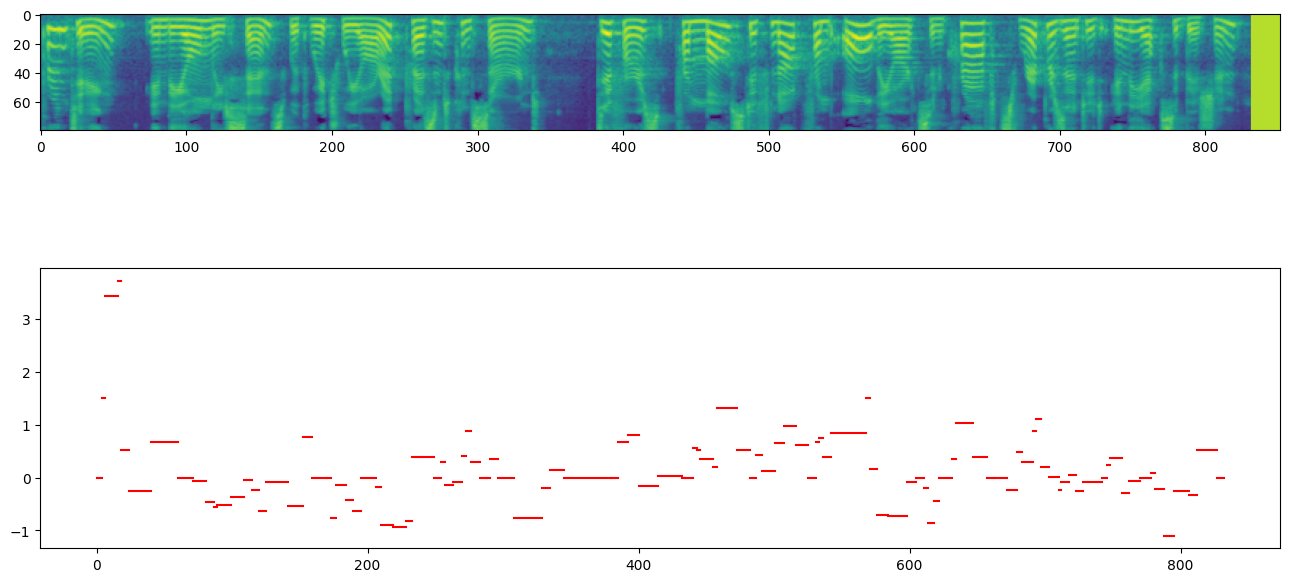

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].imshow(mel)

current_time = 0
for pitch, duration in zip(pitches, durations):
    axes[1].plot([current_time, current_time + duration], [pitch, pitch], color='red')
    current_time += duration

# 03. Implement FastPitch model (9 points)

Please implement the FastPitch model in the cell provided below. Running this cell will overwrite the model file in the repository.
- Run training (see next cells)
- Run inference (see next cells)
- When submitting the homework, please include
   - the Word Error Rate (WER) and loss curves obtained from TensorBoard as attachments,
   - the generated audio (see inference cells). If attaching an archive, use the name: `prediction.wav`

By the end of training, the loss should reach approximately 0.69, and WER should be close to zero (around 0.006). The training process will take about 30 minutes (3,000 batches).

**Important:** By the end of the training, the generated audio sample must be clear in terms of speech (WER close to 0) and maintain audio quality comparable to the original recordings (as logged in TensorBoard). **If these conditions are not met, the entire section will receive zero points**, regardless of how closely the model code resembles working code. Here is an example of how an audio from a well-trained model may sound:

In [24]:
audio, sr = sf.read('/content/speech_course/week_08_tts_am_vocoders/notebooks/prediction_example.wav')
Ipd.display(Ipd.Audio(audio, rate=sr))

In [37]:
from numpy import outer
# %%writefile /content/speech_course/week_08_tts_am_vocoders/sources/fastpitch/model.py

import torch
from torch import nn as nn
from torch.nn.utils.rnn import pad_sequence

from sources.fastpitch.common.layers import TemporalPredictor
from sources.fastpitch.common.utils import DeviceGetterMixin
from sources.fastpitch.common.utils import regulate_len
from sources.fastpitch.data import FastPitchBatch, SymbolsSet
from sources.fastpitch.hparams import HParamsFastpitch
from sources.fastpitch.common.transformer import FFTransformer

class FastPitch(nn.Module, DeviceGetterMixin):
    def __init__(self, hparams: HParamsFastpitch):
        super().__init__()
        self.hparams = hparams
        n_symbols = len(SymbolsSet().symbols_to_id)

        self.symbol_emb = nn.Embedding(n_symbols, hparams.symbols_embedding_dim)

        self.encoder = FFTransformer(
            n_layer=hparams.in_fft_n_layers,
            n_head=hparams.in_fft_n_heads,
            d_model=hparams.symbols_embedding_dim,
            d_head=hparams.in_fft_d_head,
            d_inner=4 * hparams.symbols_embedding_dim,
            kernel_size=hparams.in_fft_conv1d_kernel_size,
            dropout=hparams.p_in_fft_dropout,
            dropatt=hparams.p_in_fft_dropatt,
            dropemb=hparams.p_in_fft_dropemb
        )

        self.duration_predictor = TemporalPredictor(
            input_size=hparams.symbols_embedding_dim,
            filter_size=hparams.dur_predictor_filter_size,
            kernel_size=hparams.dur_predictor_kernel_size,
            dropout=hparams.p_dur_predictor_dropout,
            n_layers=hparams.dur_predictor_n_layers
        )

        self.pitch_predictor = TemporalPredictor(
            input_size=hparams.symbols_embedding_dim,
            filter_size=hparams.pitch_predictor_filter_size,
            kernel_size=hparams.pitch_predictor_kernel_size,
            dropout=hparams.p_pitch_predictor_dropout,
            n_layers=hparams.pitch_predictor_n_layers
        )

        self.pitch_emb = nn.Conv1d(1, hparams.symbols_embedding_dim, kernel_size=3, padding=1)

        self.decoder = FFTransformer(
            n_layer=hparams.out_fft_n_layers,
            n_head=hparams.out_fft_n_heads,
            d_model=hparams.symbols_embedding_dim,
            d_head=hparams.out_fft_d_head,
            d_inner=4 * hparams.symbols_embedding_dim,
            kernel_size=hparams.out_fft_conv1d_kernel_size,
            dropout=hparams.p_out_fft_dropout,
            dropatt=hparams.p_out_fft_dropatt,
            dropemb=hparams.p_out_fft_dropemb
        )

        self.proj = nn.Linear(hparams.symbols_embedding_dim, hparams.n_mel_channels, bias=True)

    def repeat(self, enc_out, durations):
        seqs = [
            torch.repeat_interleave(enc_out[i], durations[i], dim=0) for i in range(enc_out.shape[0])
        ]
        out = pad_sequence(seqs, batch_first=True)
        return out, durations.sum(dim=1)

    def get_encoder_out(self, batch: FastPitchBatch):
        '''
        Return:
        enc_out:
            Output of the first series of FFT blocks (before adding pitch embedding)
            shape: (batch, len(text), symbols_embedding_dim)
        enc_mask:
            Boolean padding mask for the input text sequences
            shape: (batch, len(text), 1)
        '''
        embs = self.symbol_emb(batch.texts)
        enc_out, enc_mask = self.encoder(embs, batch.text_lengths)

        return enc_out, enc_mask

    def forward(self, batch: FastPitchBatch, use_gt_durations=True, use_gt_pitch=True, max_duration=75):
        '''
        Flags `use_gt_durations` and `use_gt_pitch` should be both True during training and either True or False during inference.

        Use the function `regulate_len` to duplicate phonemes according to durations before passing them to the decoder.

        Return:
        mel_out:
            Predicted mel-spectrograms
            shape: (batch, time, mel_bins)
        mel_lens:
            Number of time frames in each of the predicted spectrograms
            shape: (batch,)
        log_dur_pred:
            The predicted log-durations for each phoneme (the output of the duration predictor).
            shape: (batch, len(text))
        dur_pred:
            The exponent of the predicted log-durations for each phoneme. Clamped to the range (0, max_duration) for numeric stability
            shape: (batch, len(text))
        pitch_pred:
            The predicted pitch for each phoneme
            shape: (batch, len(text))
        '''
        enc_out, enc_mask = self.get_encoder_out(batch)

        pitch_pred = self.pitch_predictor(enc_out, enc_mask)
        log_dur_pred = self.duration_predictor(enc_out, enc_mask)
        dur_pred = torch.clamp(torch.round(torch.exp(log_dur_pred)), 0, max_duration).long()

        if use_gt_pitch:
            pitch = batch.pitches
        else:
            pitch = pitch_pred

        pitch_embs = self.pitch_emb(pitch.unsqueeze(1)).transpose(1, 2)
        enc_out = enc_out + pitch_embs

        if use_gt_durations:
            durations = batch.durations
        else:
            durations = dur_pred

        out, mel_lens = self.repeat(enc_out, durations)

        mel_out, mel_mask = self.decoder(out, mel_lens)
        mel_out = self.proj(mel_out)

        return mel_out, mel_lens, dur_pred, log_dur_pred, pitch_pred

    @torch.no_grad()
    def infer(self, batch: FastPitchBatch, max_duration=75):
        enc_out, dur_pred, pitch_pred = self.infer_encoder(batch, max_duration=max_duration)
        mel_out, mel_lens = self.infer_decoder(enc_out, dur_pred)
        return mel_out, mel_lens, dur_pred, pitch_pred

    def infer_encoder(self, batch: FastPitchBatch, max_duration=75):
        enc_out, enc_mask = self.get_encoder_out(batch)

        pitch_pred = self.pitch_predictor(enc_out, enc_mask)
        log_dur_pred = self.duration_predictor(enc_out, enc_mask)

        dur_pred = torch.clamp(torch.round(torch.exp(log_dur_pred)), 0, max_duration).long()

        pitch_embs = self.pitch_emb(pitch_pred.unsqueeze(1)).transpose(1, 2)
        enc_out = enc_out + pitch_embs

        return enc_out, dur_pred, pitch_pred

    def infer_decoder(self, enc_out, dur_pred):
        out, mel_lens = self.repeat(enc_out, dur_pred)
        mel_out, mel_mask = self.decoder(out, mel_lens)
        mel_out = self.proj(mel_out)
        return mel_out, mel_lens


In [ ]:
 # Allows reloading code import without kernel restart
%load_ext autoreload
%autoreload 2

In [ ]:
from sources.fastpitch.model import FastPitch

In [ ]:
fp = FastPitch(hparams)

In [ ]:
enc_out, enc_mask = fp.get_encoder_out(batch)

In [ ]:
assert enc_out.shape == torch.Size([hparams.batch_size, batch.texts.shape[1], hparams.symbols_embedding_dim])
assert enc_mask.shape == torch.Size([hparams.batch_size, batch.texts.shape[1], 1])

In [ ]:
mel_out, mel_lens, dur_pred, log_dur_pred, pitch_pred = fp.forward(batch)

In [ ]:
assert mel_out.shape == batch.mels.transpose(2, 1).shape
assert mel_lens.shape == batch.mel_lengths.shape
assert dur_pred.shape == batch.texts.shape
assert dur_pred.shape == log_dur_pred.shape
assert pitch_pred.shape == batch.texts.shape

### Run training

In [ ]:
logs_dir = "logs"     # Choose any paths
ckpt_dir = "checkpoints"

In [ ]:
os.makedirs(logs_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

In [ ]:
sp.check_call(
    ' '.join([
        f'PYTHONPATH={path_to_sources} CUDA_VISIBLE_DEVICES={gpu_avaiable}',
        f'python3 -m sources.fastpitch.train_fastpitch',
        f'--logs {logs_dir}',
        f'--ckptdir {ckpt_dir}',
        f'--dataset {path_to_dataset}',
        f'--hfg {path_to_hfg_ckpt}'
    ]), shell=True
)

In [ ]:
# If running in colab:

# %load_ext tensorboard
# %tensorboard --logdir logs

In [ ]:
# If running in colab:

# %%shell

# mkdir logs checkpoints

# PYTHONPATH=speech_course python3 -m week_07_tts_am.fastpitch.train_fastpitch  \
# --logs logs \
# --ckptdir checkpoints \
# --dataset /content/ljspeech_aligned \
# --hfg /content/hifigan_gen_checkpoint_6500.pt

### Infer model on an example

Execute the code provided below. Then, append the generated audio to the homework results.
- if attaching an archive, use name: `prediction.wav`

In [ ]:
from sources.fastpitch.common.checkpointer import Checkpointer
from sources.fastpitch.model import FastPitch
from sources.fastpitch.data import FastPitchBatch, SymbolsSet
from sources.hifigan.model import load_model as load_hfg_model

In [ ]:
def get_symbol_ids(text):
    g2p = G2p()
    phonemes = g2p(text)

    symbols_set = SymbolsSet()

    symbols = []
    for ph in phonemes:
        if ph in symbols_set.symbols_to_id:
            symbols.append(ph)
        elif ph == ' ':
            continue
        else:
            symbols.append("sil")

    symbols_ids = torch.LongTensor(symbols_set.encode(symbols))
    text_length = torch.LongTensor([symbols_ids.shape[0]])

    return symbols_ids, text_length

In [ ]:
checkpointer = Checkpointer(ckpt_dir)

In [ ]:
hfg = load_hfg_model(path_to_hfg_ckpt)
hfg = hfg.to(device).eval()

In [ ]:
ckpt_dict = checkpointer.load_last_checkpoint()
hparams = HParamsFastpitch.create(ckpt_dict['hparams'])
fp = FastPitch(hparams)
fp.load_state_dict(ckpt_dict['state_dict'])
fp = fp.to(device)

In [ ]:
text = "Freestyler, rock the microphone, straight from the top of my dome. Freestyler, rock the microphone, carry on with the freestyler."

In [ ]:
symbols_ids, lengths = get_symbol_ids(text)

batch = FastPitchBatch(
    texts=symbols_ids.unsqueeze(0),
    text_lengths=lengths
).to(device)

In [ ]:
with torch.no_grad():
    mels, mel_lens, *_ = fp.infer(batch)
    mels = mels.permute(0, 2, 1)
    audio = hfg(mels)

Ipd.display(Ipd.Audio(audio.squeeze().cpu().detach().numpy(), rate=22050))

### Pitch & duration manipulations (1 point)

- **(0.5 points)** Try increasing and decreasing the prediction speed by a factor of 2, draw spectrograms for each case
    - if attaching an archive, use names:  `prediction_half_dur.wav`,  `prediction_double_dur.wav`
- **(0.5 points)** Try shifting prediction pitch 50 Hz up and down, draw spectrograms for each case
    - if attaching an archive, use names:  `prediction_50hz_up.wav`,  `prediction_50hz_down.wav`

Аttach resulting audio files to the homework report.

In [ ]:
def scale_durations(durations: torch.Tensor, scale_factor: float):
    <YOUR CODE HERE>


def shift_pitch(pitch: torch.Tensor, shift: float):
    scale = 62.51305    # Mean and variance of pitch in LJSpeech used for target pitch normalization
    mean = 215.42230
    <YOUR CODE HERE>

In [ ]:
_, dur_pred, pitch_pred = fp.infer_encoder(batch)

In [ ]:
batch = FastPitchBatch(
    texts=symbols_ids.unsqueeze(0),
    text_lengths=lengths,
    pitches=shift_pitch(pitch_pred, shift=0),
    durations=scale_durations(dur_pred, scale_factor=2)
).to(device)

In [ ]:
with torch.no_grad():
    mels, mel_lens, *_ = fp(batch, use_gt_durations=True, use_gt_pitch=True)
    mels = mels.permute(0, 2, 1)
    audio = hfg(mels)

Ipd.display(Ipd.Audio(audio.squeeze().cpu().detach().numpy(), rate=22050))
plt.imshow(mels.squeeze().cpu().detach().numpy())
plt.show()